In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nlp-getting-started/sample_submission.csv
/kaggle/input/competitions/nlp-getting-started/train.csv
/kaggle/input/competitions/nlp-getting-started/test.csv


In [2]:
import os
import pandas as pd

# Show available files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/nlp-getting-started/sample_submission.csv
/kaggle/input/competitions/nlp-getting-started/train.csv
/kaggle/input/competitions/nlp-getting-started/test.csv


In [3]:
import pandas as pd

train = pd.read_csv(
    "/kaggle/input/competitions/nlp-getting-started/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/nlp-getting-started/test.csv"
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (7613, 5)
Test shape: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nMissing values:")
print(train.isnull().sum())

print("\nTarget distribution:")
print(train["target"].value_counts())

Train columns:
['id', 'keyword', 'location', 'text', 'target']

Missing values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Target distribution:
target
0    4342
1    3271
Name: count, dtype: int64


In [5]:
X = train["text"].fillna("")
y = train["target"]

X_test = test["text"].fillna("")

print("Training samples:", len(X))
print("Test samples:", len(X_test))

Training samples: 7613
Test samples: 3263


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

Training: 6090
Validation: 1523


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

print("Training features:", X_train_tfidf.shape)
print("Validation features:", X_val_tfidf.shape)

Training features: (6090, 20000)
Validation features: (1523, 20000)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    C=1.0
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully.")

Model trained successfully.


In [9]:
val_prob = model.predict_proba(X_val_tfidf)[:, 1]

print(val_prob[:10])

[0.57041014 0.3867103  0.8130819  0.27112181 0.05310523 0.2450249
 0.5529872  0.09086399 0.4196861  0.22712218]


In [10]:
from sklearn.metrics import f1_score

val_pred = (val_prob >= 0.50).astype(int)

f1 = f1_score(y_val, val_pred)

print("Validation F1 Score:", round(f1, 4))

Validation F1 Score: 0.761


In [11]:
import numpy as np

thresholds = np.arange(0.10, 1.00, 0.01)
scores = []

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)
    score = f1_score(y_val, val_pred)
    scores.append(score)

print("Threshold testing completed.")

Threshold testing completed.


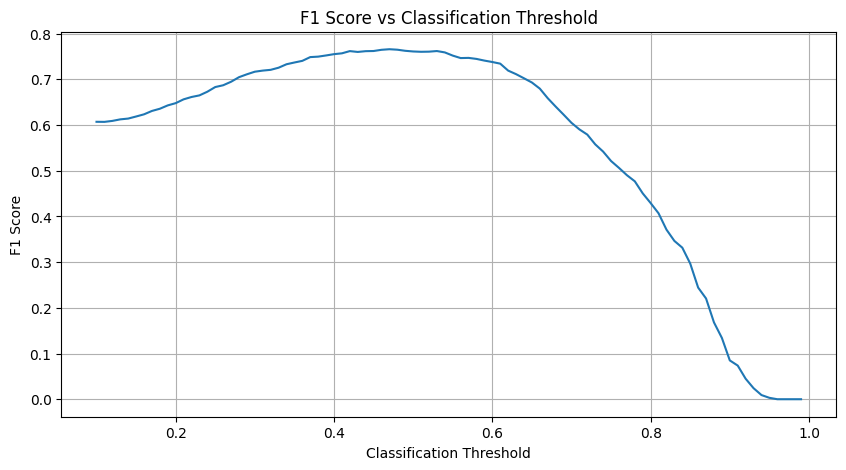

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(thresholds, scores)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")

plt.grid(True)
plt.show()

In [13]:
best_index = np.argmax(scores)

best_threshold = thresholds[best_index]
best_f1 = scores[best_index]

print("Best Threshold:", round(best_threshold, 2))
print("Best Validation F1:", round(best_f1, 4))

Best Threshold: 0.47
Best Validation F1: 0.7659


In [14]:
from sklearn.metrics import classification_report

best_val_pred = (val_prob >= best_threshold).astype(int)

print(classification_report(y_val, best_val_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       869
           1       0.78      0.76      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



In [15]:
final_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_full_tfidf = final_vectorizer.fit_transform(X)
X_test_tfidf = final_vectorizer.transform(X_test)

final_model = LogisticRegression(
    max_iter=1000,
    C=1.0
)

final_model.fit(X_full_tfidf, y)

print("Final model trained successfully.")

Final model trained successfully.


In [16]:
test_prob = final_model.predict_proba(X_test_tfidf)[:, 1]

test_pred = (test_prob >= best_threshold).astype(int)

print("Predictions created.")
print(test_pred[:20])

Predictions created.
[1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]


In [17]:
submission = pd.DataFrame({
    "id": test["id"],
    "target": test_pred
})

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("Submission file created!")
print(submission.head())

Submission file created!
   id  target
0   0       1
1   2       0
2   3       1
3   9       0
4  11       1


In [18]:
print(submission.shape)
print(submission["target"].value_counts())
print(submission.head(10))

(3263, 2)
target
0    2031
1    1232
Name: count, dtype: int64
   id  target
0   0       1
1   2       0
2   3       1
3   9       0
4  11       1
5  12       1
6  21       0
7  22       0
8  27       0
9  29       0
